Primer Parcial

Estudiante: Chelsea Melany Espinoza Cava

Carrera: Ing. de Sistemas

ste archivo se refiere a solicitudes de tarjetas de crédito.
En Australia

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [13]:
# 1. CARGA DE DATOS
# El archivo australian.dat usa espacios como separador y no tiene cabecera
# Definimos nombres genéricos del A1 al A14 + la columna Target
columnas = [f'A{i}' for i in range(1, 15)] + ['Target']
df_aus = pd.read_csv('australian.dat', sep='\s+', names=columnas)

print(f"--- Dataset 7: Crédito Australiano ---")
print(f"Dimensiones: {df_aus.shape}")
df_aus.head()

--- Dataset 7: Crédito Australiano ---
Dimensiones: (690, 15)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Target
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [14]:
# Verificar nulos
print("\n--- Conteo de Nulos por Columna ---")
nulos = df_aus.isnull().sum()
print(nulos[nulos > 0])

print(f"\nTotal general de nulos: {df_aus.isnull().sum().sum()}")


--- Conteo de Nulos por Columna ---
Series([], dtype: int64)

Total general de nulos: 0


In [15]:
# El KNN no puede procesar palabras, así que convertimos todo a números primero.
le = LabelEncoder()
for col in df_aus.columns:
    if df_aus[col].dtype == 'object':
        df_aus[col] = le.fit_transform(df_aus[col].astype(str))
print("\n¡Letras convertidas a números con éxito!")


¡Letras convertidas a números con éxito!


In [16]:
# 3. NORMALIZACIÓN Z-SCORE (StandardScaler)
# Fundamental porque hay variables continuas y categóricas mezcladas
scaler = StandardScaler()

# Separamos X y y antes de escalar
X_raw = df_aus.drop('Target', axis=1)
y = df_aus['Target'].values

# Escalamos las características (X)
X_scaled = scaler.fit_transform(X_raw)

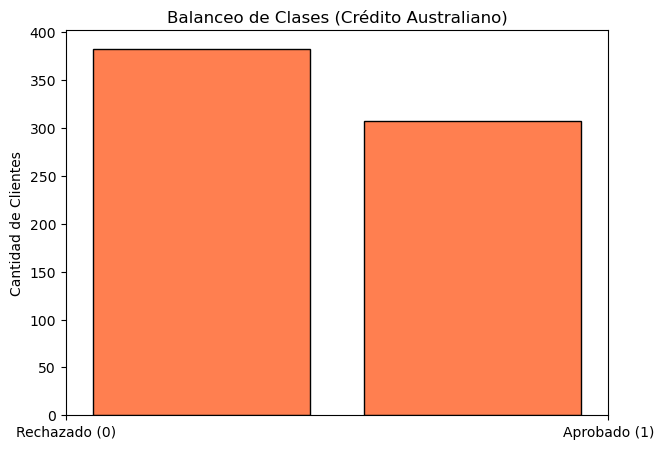

In [17]:
plt.figure(figsize=(7, 5))
plt.hist(y, bins=2, color='coral', edgecolor='black', rwidth=0.8)
plt.title('Balanceo de Clases (Crédito Australiano)')
plt.xticks([0, 1], ['Rechazado (0)', 'Aprobado (1)'])
plt.ylabel('Cantidad de Clientes')
plt.show()

In [18]:
# 5. DIVISIÓN TRAIN / TEST (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)
print(f"Entrenamiento (X_train): {X_train.shape}")
print(f"Prueba (X_test): {X_test.shape}")

Entrenamiento (X_train): (552, 14)
Prueba (X_test): (138, 14)


In [19]:
print(f"¿Quedan nulos en el dataset?: {df_final_nhanes.isnull().sum().sum()}")
print(f"Registros totales procesados: {df_final_nhanes.shape[0]}")


¿Quedan nulos en el dataset?: 0
Registros totales procesados: 690
